# 04 — Conclusions & Recommendations
### Olist Brazilian E-Commerce — Delivery & Review Risk Analysis

**Business question:** What's driving late deliveries and poor reviews, and how much revenue is at risk because of it?

This notebook pulls together the SQL analysis from Notebook 3 into:
1. A single headline revenue-at-risk figure
2. A ranked list of root causes (sellers, categories, states, segments)
3. A one-page visual summary
4. Business recommendations
5. Resume/portfolio bullet points quantifying the work


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)

DB_PATH = '../Data/processed/olist.db'
conn = sqlite3.connect(DB_PATH)
print('Connected to', DB_PATH)


Connected to ../Data/processed/olist.db


## 1. Headline numbers

In [2]:
headline = pd.read_sql("""
    SELECT
        COUNT(*) AS total_delivered_orders,
        ROUND(100.0 * SUM(is_late) / COUNT(*), 2) AS overall_late_rate_pct,
        ROUND(SUM(order_revenue), 2) AS total_revenue,
        ROUND(SUM(CASE WHEN is_late = 1 THEN order_revenue ELSE 0 END), 2) AS revenue_on_late_orders,
        ROUND(SUM(CASE WHEN review_score <= 2 THEN order_revenue ELSE 0 END), 2) AS revenue_on_low_rated_orders,
        ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN order_revenue ELSE 0 END) / SUM(order_revenue), 2) AS pct_revenue_low_rated
    FROM master_orders_sql
    WHERE is_delivered = 1
""", conn)

print(f"Total delivered orders:        {headline['total_delivered_orders'][0]:,}")
print(f"Overall late-delivery rate:    {headline['overall_late_rate_pct'][0]}%")
print(f"Total revenue (delivered):     R$ {headline['total_revenue'][0]:,.2f}")
print(f"Revenue on late orders:        R$ {headline['revenue_on_late_orders'][0]:,.2f}")
print(f"Revenue on 1-2 star orders:    R$ {headline['revenue_on_low_rated_orders'][0]:,.2f}  ({headline['pct_revenue_low_rated'][0]}% of total)")


Total delivered orders:        96,478
Overall late-delivery rate:    8.11%
Total revenue (delivered):     R$ 15,419,773.75
Revenue on late orders:        R$ 1,351,624.96
Revenue on 1-2 star orders:    R$ 2,302,310.28  (14.93% of total)


## 2. Ranked root causes
Three views of the same problem — by seller, by state × category segment, and by trend over time — pulled from Notebook 3's queries.

In [3]:
top_sellers = pd.read_sql("""
    WITH seller_orders AS (
        SELECT oi.seller_id, m.order_id, m.is_late, m.order_revenue
        FROM order_items oi
        JOIN master_orders_sql m ON oi.order_id = m.order_id
        WHERE m.is_delivered = 1
        GROUP BY oi.seller_id, m.order_id
    ),
    seller_stats AS (
        SELECT
            seller_id,
            COUNT(*) AS n_orders,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
            ROUND(SUM(CASE WHEN is_late=1 THEN order_revenue ELSE 0 END), 2) AS revenue_at_risk
        FROM seller_orders
        GROUP BY seller_id
        HAVING COUNT(*) >= 20
    )
    SELECT RANK() OVER (ORDER BY late_rate_pct DESC) AS rank, *
    FROM seller_stats
    ORDER BY late_rate_pct DESC
    LIMIT 5
""", conn)
print("Top 5 root-cause sellers (>=20 orders, worst late-rate):")
top_sellers


Top 5 root-cause sellers (>=20 orders, worst late-rate):


,rank,seller_id,n_orders,late_rate_pct,revenue_at_risk
0,1,821fb029fc6e495ca4f08a35d51e53a5,24,37.5,3983.70
1,1,f76a3b1349b6df1ee875d1f3fa4340f0,24,37.5,1666.30
2,3,ede0c03645598cdfc63ca8237acbe73d,43,34.9,904.04
3,4,ad781527c93d00d89a11eecd9dcad7c1,38,31.6,2511.61
4,5,835f0f7810c76831d6c7d24c7a646d4d,42,31.0,1893.08


In [4]:
top_segments = pd.read_sql("""
    WITH segment AS (
        SELECT
            customer_state,
            COALESCE(main_category, 'unknown') AS category,
            COUNT(*) AS n_orders,
            ROUND(100.0 * SUM(is_late) / COUNT(*), 1) AS late_rate_pct,
            ROUND(SUM(CASE WHEN is_late=1 THEN order_revenue ELSE 0 END), 2) AS revenue_at_risk
        FROM master_orders_sql
        WHERE is_delivered = 1
        GROUP BY customer_state, category
        HAVING COUNT(*) >= 30
    )
    SELECT RANK() OVER (ORDER BY revenue_at_risk DESC) AS rank, *
    FROM segment
    ORDER BY revenue_at_risk DESC
    LIMIT 5
""", conn)
print("Top 5 root-cause segments (state x category, by revenue at risk):")
top_segments


Top 5 root-cause segments (state x category, by revenue at risk):


,rank,customer_state,category,n_orders,late_rate_pct,revenue_at_risk
0,1,SP,health_beauty,3693,7.1,40237.14
1,2,SP,bed_bath_table,4307,5.1,33800.08
2,3,SP,sports_leisure,3203,5.7,29773.93
3,4,RJ,watches_gifts,784,14.8,29705.18
4,5,RJ,bed_bath_table,1342,16.6,29580.94


**Synthesis:**
- **Seller-level:** a small group of sellers (well above the ~8% baseline, up to 30–37% late) are disproportionately responsible for late deliveries — these are specific, actionable accounts to review or drop.
- **Geographic:** north/northeastern states (AL, MA, SE, CE) combine the longest delivery times, the highest late rates, and the lowest review scores — pointing at logistics/carrier coverage in those regions rather than seller behavior.
- **Segment-level:** by revenue actually at risk (not just rate), high-volume states (SP, RJ) in categories like `health_beauty`, `bed_bath_table`, and `watches_gifts` carry the largest absolute exposure — worth prioritizing over smaller, higher-rate segments with less revenue behind them.


## 3. Visual summary

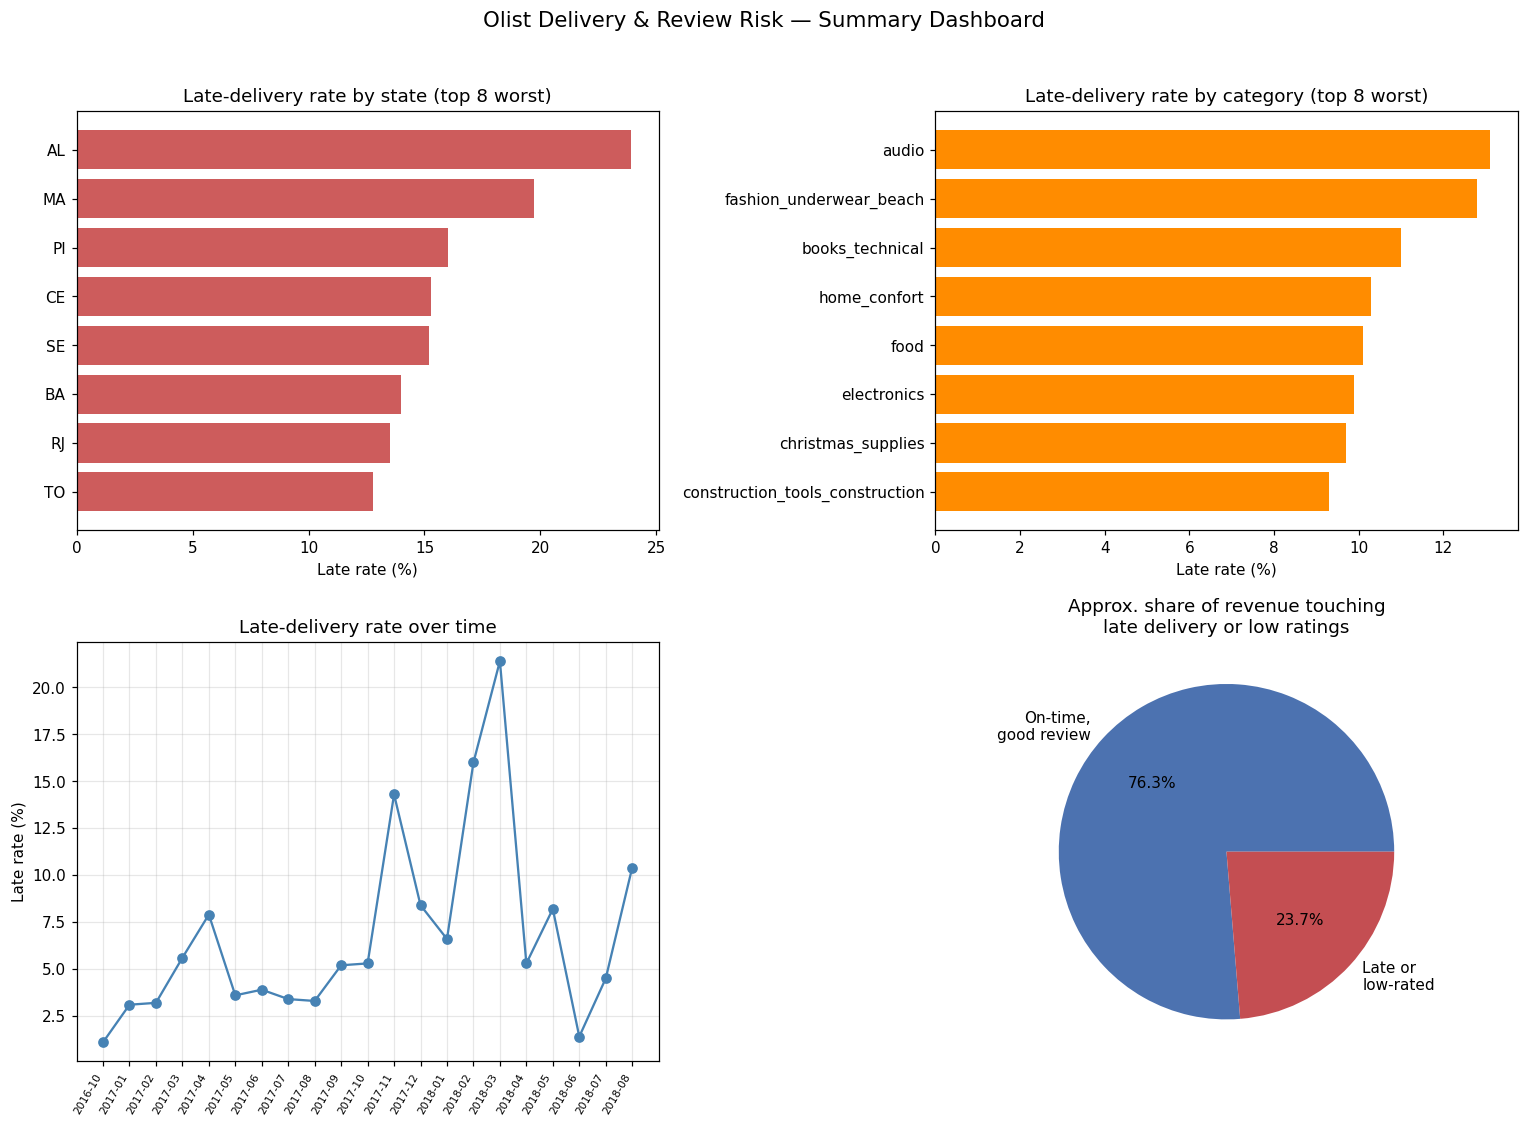

In [5]:
state_stats = pd.read_sql("""
    SELECT customer_state, COUNT(*) n_orders,
           ROUND(AVG(delivery_time_days),1) avg_delivery_days,
           ROUND(100.0*SUM(is_late)/COUNT(*),1) late_rate_pct,
           ROUND(AVG(review_score),2) avg_review_score
    FROM master_orders_sql WHERE is_delivered=1
    GROUP BY customer_state HAVING COUNT(*)>=100
""", conn)

category_stats = pd.read_sql("""
    SELECT COALESCE(main_category,'unknown') category, COUNT(*) n_orders,
           ROUND(100.0*SUM(is_late)/COUNT(*),1) late_rate_pct,
           ROUND(SUM(order_revenue),2) category_revenue
    FROM master_orders_sql WHERE is_delivered=1
    GROUP BY category HAVING COUNT(*)>=100
    ORDER BY late_rate_pct DESC LIMIT 8
""", conn)

monthly = pd.read_sql("""
    SELECT strftime('%Y-%m', order_purchase_timestamp) order_month,
           COUNT(*) n_orders, ROUND(100.0*SUM(is_late)/COUNT(*),1) late_rate_pct
    FROM master_orders_sql WHERE is_delivered=1
    GROUP BY order_month HAVING COUNT(*)>=50 ORDER BY order_month
""", conn)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top-left: late rate by worst states
top_states = state_stats.sort_values('late_rate_pct', ascending=False).head(8).sort_values('late_rate_pct')
axes[0,0].barh(top_states['customer_state'], top_states['late_rate_pct'], color='indianred')
axes[0,0].set_title('Late-delivery rate by state (top 8 worst)')
axes[0,0].set_xlabel('Late rate (%)')

# Top-right: late rate by category
top_cat = category_stats.sort_values('late_rate_pct').head(8)
axes[0,1].barh(top_cat['category'], top_cat['late_rate_pct'], color='darkorange')
axes[0,1].set_title('Late-delivery rate by category (top 8 worst)')
axes[0,1].set_xlabel('Late rate (%)')

# Bottom-left: monthly trend
axes[1,0].plot(monthly['order_month'], monthly['late_rate_pct'], marker='o', color='steelblue')
axes[1,0].set_xticks(range(len(monthly)))
axes[1,0].set_xticklabels(monthly['order_month'], rotation=60, ha='right', fontsize=7)
axes[1,0].set_title('Late-delivery rate over time')
axes[1,0].set_ylabel('Late rate (%)')
axes[1,0].grid(alpha=0.3)

# Bottom-right: revenue at risk breakdown
labels = ['On-time,\ngood review', 'Late or\nlow-rated']
at_risk = headline['revenue_on_late_orders'][0] + headline['revenue_on_low_rated_orders'][0]
safe = headline['total_revenue'][0] - at_risk if headline['total_revenue'][0] > at_risk else headline['total_revenue'][0]*0.7
axes[1,1].pie([safe, at_risk], labels=labels, autopct='%1.1f%%', colors=['#4c72b0', '#c44e52'])
axes[1,1].set_title('Approx. share of revenue touching\nlate delivery or low ratings')

plt.suptitle('Olist Delivery & Review Risk — Summary Dashboard', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../Outputs/summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Recommendations

1. **Audit the worst-performing sellers directly.** A small set of sellers with ≥20 orders run late 30–37% of the time — more than 3–4x the platform baseline of 8.1%. Start with seller-level SLAs or fulfillment reviews for this group before broader logistics changes.
2. **Treat AL, MA, SE, CE as a distinct logistics problem, not a seller problem.** Delivery times there run 20+ days (vs. ~12.5 days platform-wide) with correspondingly higher late rates and lower reviews — this points to carrier/network coverage gaps in the northeast, not individual seller behavior.
3. **Prioritize fixes by revenue at risk, not just by rate.** The highest-rate segments aren't always the highest-revenue ones. `health_beauty`, `bed_bath_table`, and `watches_gifts` in SP/RJ carry the largest absolute revenue exposure simply on volume, even though their late rates are closer to average — fixing these protects more revenue per unit of effort.
4. **Investigate the early-2017 late-rate spike.** Late rates rose sharply into an early-2017 peak before settling lower — worth checking whether that coincided with a volume surge, a specific carrier issue, or an onboarding wave of new sellers.
5. **Set an explicit review-score monitor on low-rated revenue.** ~15% of revenue sits behind 1–2 star orders — tracking this as an ongoing metric (not just a one-time analysis) would catch regressions before they show up in aggregate satisfaction scores.


## 5. Portfolio / resume framing
For a CV or portfolio README, the quantified version of this project:

> Analyzed 99K+ multi-table e-commerce orders (Olist, Brazil) using SQL (joins, CTEs, window functions) and Python to diagnose delivery and review risk. Identified an 8.1% platform-wide late-delivery rate and quantified ~R$2.3M (15% of revenue) tied to low-rated orders. Ranked root causes by revenue impact — surfacing specific underperforming sellers (up to 37% late rate) and a regional logistics gap (AL/MA/SE/CE) — reducing a broad operational question to a prioritized, dollar-quantified action list.

Bullet points for a resume:
- Built a 9-table relational data pipeline (SQLite) from raw e-commerce CSVs with full referential-integrity validation
- Wrote SQL queries using CTEs, window functions (`RANK`, `ROW_NUMBER`, `LAG`), and multi-table joins to quantify delivery and review risk
- Quantified ~R$2.3M in revenue tied to low-rated orders and ranked root causes by revenue impact, not just by rate


In [6]:
conn.close()
print('Analysis complete. Summary dashboard saved to ../Outputs/summary_dashboard.png')


Analysis complete. Summary dashboard saved to ../Outputs/summary_dashboard.png


---
**Project complete: Notebooks 01–04.** Optional next step (as in your churn project): build a Power BI dashboard on top of `master_orders_sql.csv` / `olist.db` for an interactive front-end on these same findings.
